In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import numpy as np
from math import pi
from qiskit.quantum_info import Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import SGate, XGate, UnitaryGate, IGate
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

import numpy as np
from qiskit.circuit.library import UnitaryGate
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

service = QiskitRuntimeService(channel="ibm_cloud",
            token="", # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
            instance='') 
service.backends()

# --- Matrix ---
c1 = np.pi/2
c2 = np.pi/4

theta1 = (c1 - c2)
theta2 = (c1 + c2)

U = np.array([
    [np.cos(theta1), 0, 0, -1j*np.sin(theta1)],
    [0, np.cos(theta2), -1j*np.sin(theta2), 0],
    [0, -1j*np.sin(theta2), np.cos(theta2), 0],
    [-1j*np.sin(theta1), 0, 0, np.cos(theta1)]
])

B = Operator(U)

def b_tilde(B_op: Operator):
    S = SGate().to_matrix()
    X = XGate().to_matrix()

    return UnitaryGate(np.kron(S, X) @ B_op.data @ np.kron(S, X), label="B_tilde")

u_final = b_tilde(B)

all_pairs = ['00','01','10','11']
circuits = []

for pair in all_pairs:
    qc = QuantumCircuit(2, 2)

    # --- Entanglement creation (UNCHANGED) ---
    qc.h(1)
    qc.cx(1, 0)
    qc.barrier()

    # --- Alice encoding (UPDATED) ---
    if pair == '00':
        qc.z(0)
    elif pair == '01':
        qc.z(0)
        qc.x(0)
    elif pair == '10':
        qc.x(0)
    elif pair == '11':
     #  pass  # Identity

     
    if pair == '11':
        qc.z(0)
    elif pair == '01':
        qc.z(0)
        qc.x(0)
    elif pair == '10':
        qc.x(0)
    elif pair == '00':
       pass  # Identity

    qc.barrier()

    # --- Bob decoding using B-tilde dagger ---
    qc.append(u_final, [1, 0])
    qc.barrier()

    # --- Measurement ---
    qc.measure(0, 0)
    qc.measure(1, 1)
    circuits.append(qc)


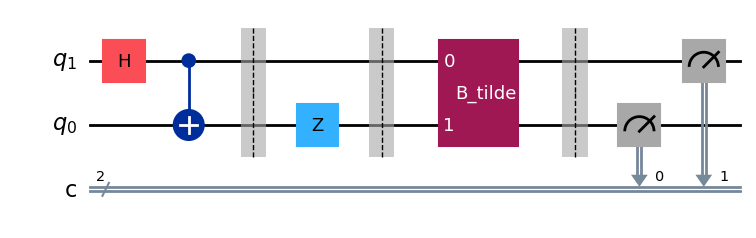

ibm_fez
{'00': {'11': 9579, '00': 153, '01': 148, '10': 120}, '01': {'01': 9374, '00': 287, '10': 234, '11': 105}, '10': {'10': 8989, '00': 593, '01': 363, '11': 55}, '11': {'00': 9015, '10': 158, '01': 603, '11': 224}}


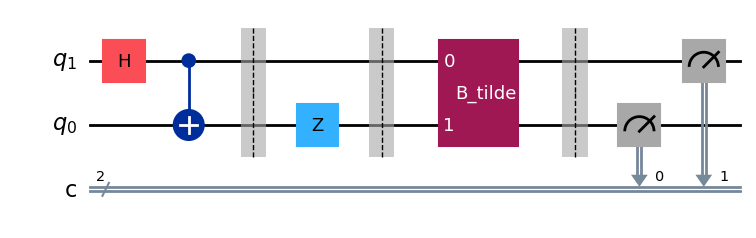

In [ ]:
display(qc.draw(output='mpl', reverse_bits=True))


backend = service.least_busy(operational=True, simulator=False, min_num_qubits=5)
print(backend.name)
target = backend.target

pm = generate_preset_pass_manager(target=target, optimization_level=3, layout_method= 'sabre')
circuits_isa = pm.run(circuits)

sampler = Sampler(mode=backend)
job = sampler.run(circuits_isa, shots=10000)
res = job.result()

counts_dict = {}

for i, pair in enumerate(all_pairs):
    pub = res[i]
    counts_dict[pair] = pub.join_data().get_counts()
print(counts_dict)

In [10]:
for pair in all_pairs:
    print(pair, counts_dict[pair])

00 {'11': 9579, '00': 153, '01': 148, '10': 120}
01 {'01': 9374, '00': 287, '10': 234, '11': 105}
10 {'10': 8989, '00': 593, '01': 363, '11': 55}
11 {'00': 9015, '10': 158, '01': 603, '11': 224}


In [11]:
%matplotlib inline

inline


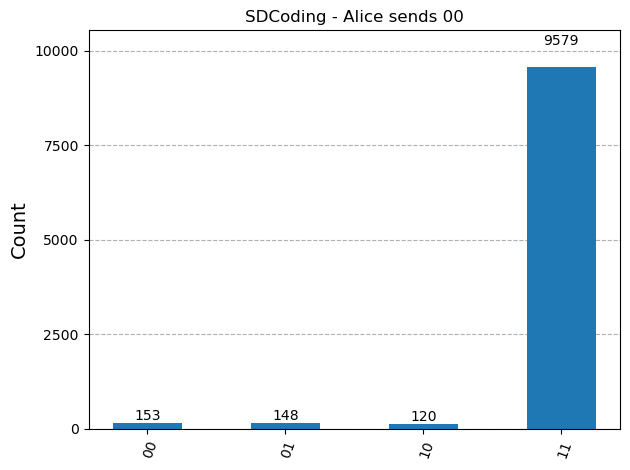

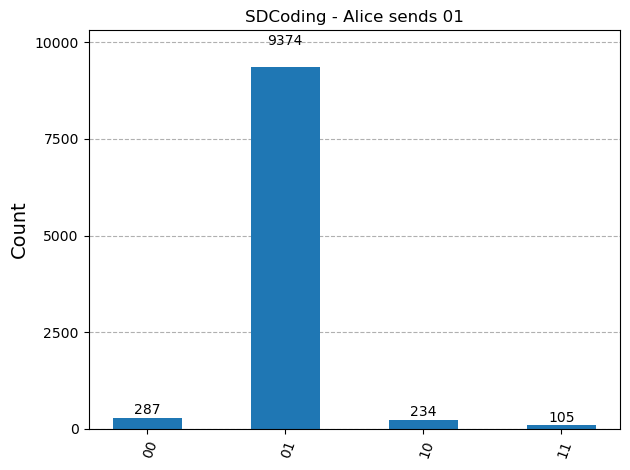

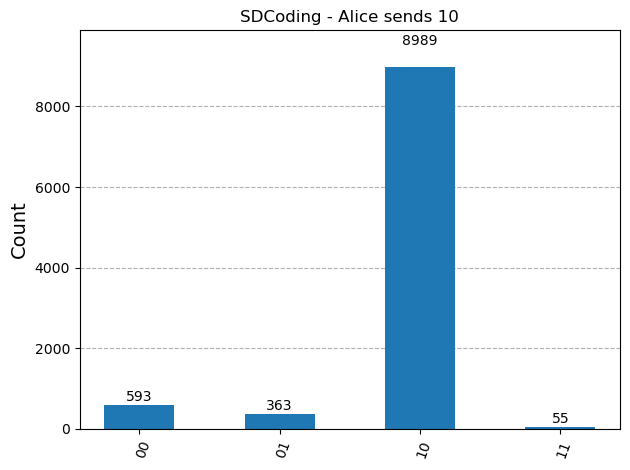

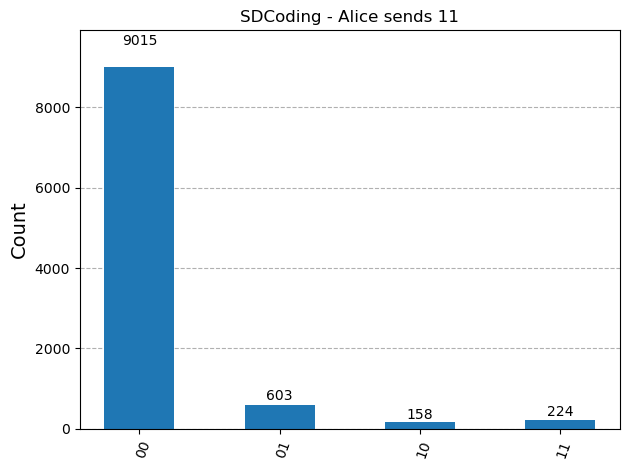

In [12]:
import matplotlib.pyplot as plt
print(plt.get_backend())
for pair in all_pairs:
    fig=plot_histogram(
            counts_dict[pair],
            title=f"SDCoding - Alice sends {pair}"
        )
    plt.show()

In [13]:
for pair, counts in counts_dict.items():
    print(pair, "→ dominant:", max(counts, key=counts.get))

00 → dominant: 11
01 → dominant: 01
10 → dominant: 10
11 → dominant: 00


In [14]:
success_pct = {}

for pair, counts in counts_dict.items():
    total_shots = sum(counts.values())
    correct_shots = counts.get(pair, 0)
    success_pct[pair] = 100 * correct_shots / total_shots

for pair in sorted(success_pct):
    print(f"Alice sent {pair} → Success = {success_pct[pair]:.2f}%")

Alice sent 00 → Success = 1.53%
Alice sent 01 → Success = 93.74%
Alice sent 10 → Success = 89.89%
Alice sent 11 → Success = 2.24%
